## **Analysis of Delhi Air pollution as a project**
Motivation to make this project is personal,being a civil service aspirant in the past made me think and analyze the topics affecting the lives of common people.This project is attached with some analytical insights regarding the air quality of NCT Delhi.
This project uses only python libraries like Pandas and Matplotlib for data visualization.
Disclaimer:This project is public so free to take ideas from it copy the necessary. Your keen interest and capability of turning it into something useful for the society will be my source of Honour.



# Table Of Content :

Import Libraries

Load and Understand the Data

Exploratory Data Analysis (EDA)

Data Cleaning & Preprocessing

Feature Engineering

Data Visualization

Model Building & Evaluation

Conclusion & Insights

Future Work

Step 1.Import Libraries & Load Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kunshbhatia/delhi-air-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kunshbhatia/delhi-air-quality-dataset


Step 2: Explore Dataset Structure

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os # Import the os module for path manipulation
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
# Use the 'path' variable from the previous cell and os.path.join to construct the correct file path
excel_file_path = os.path.join(path, 'Cleaned_NSUT.xlsx')
df = pd.read_excel(excel_file_path)

# Check what we have
print("📊 DATASET OVERVIEW")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

📊 DATASET OVERVIEW
Shape: (1461, 12)

First 5 rows:
   Date  Month  Year  Holidays_Count  Days   PM2.5    PM10    NO2    SO2  \
0     1      1  2021               0     5  180.57  458.90  42.35  10.03   
1     2      1  2021               0     6  146.71  371.52  27.41  10.05   
2     3      1  2021               1     7   76.94  190.39  13.17  10.32   
3     4      1  2021               0     1   58.12  111.38  67.60  12.79   
4     5      1  2021               0     2   44.66   86.96  55.96   9.97   

     CO  Ozone    AQI  
0  1.57  19.04  336.0  
1  1.14  13.37  351.0  
2  0.96  14.67  241.0  
3  1.01  12.77   90.0  
4  1.41  15.82   99.0  

Column names:
['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']

Data types:
Date                int64
Month               int64
Year                int64
Holidays_Count      int64
Days                int64
PM2.5             float64
PM10              float64
NO2               float64
SO2   


 Key Insight:

1.Date Representation Issue

What: Date column is integer (1-31), not datetime

Why This Matters:

You cannot properly analyze time-based patterns

Your dataset spans across multiple months/years but dates are just day numbers

Need to combine Date, Month, Year into proper datetime format

Action Required: Create a proper date column

2.High Pollution Levels 🚨
PM2.5: Ranges from 44 to 180 µg/m³ (extremely high)

PM10: Ranges from 86 to 458 µg/m³ (severe)

AQI: Ranges from 90 to 351 (from "Moderate" to "Hazardous")

Context:

PM2.5 > 250 = Hazardous (your max is 180)

PM2.5 > 100 = Very Unhealthy

Your values indicate severe air quality issues

3.Holiday Impact Variable
Holidays_Count: Shows 0 or 1

Likely Insight: Air quality may change significantly on holidays

Hypothesis:

Lower pollution on holidays (less traffic, industry)

Higher pollution on certain holidays (firecrackers/festivals)

4.Weekly Pattern Potential
Days: Values 1-7 (Monday to Sunday)



Exploring dataset structure is the FIRST and MOST CRITICAL step in any data analysis project.
1. Understand What You're Working With
2. Data Quality Assessment
3. Plan Your Analysis Strategy
4. Business Impact

Step 3: Data Cleaning

In [3]:
print("\n📋 COLUMN INFORMATION")
print(df.columns.tolist())

print("\n📊 DATA TYPES")
print(df.dtypes)

print("\n📈 STATISTICAL SUMMARY")
print(df.describe())

print("\n❓ MISSING VALUES")
print(df.isnull().sum())


📋 COLUMN INFORMATION
['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']

📊 DATA TYPES
Date                int64
Month               int64
Year                int64
Holidays_Count      int64
Days                int64
PM2.5             float64
PM10              float64
NO2               float64
SO2               float64
CO                float64
Ozone             float64
AQI               float64
dtype: object

📈 STATISTICAL SUMMARY
              Date        Month         Year  Holidays_Count         Days  \
count  1461.000000  1461.000000  1461.000000     1461.000000  1461.000000   
mean     15.729637     6.522930  2022.501027        0.189596     4.000684   
std       8.803105     3.449884     1.118723        0.392116     2.001883   
min       1.000000     1.000000  2021.000000        0.000000     1.000000   
25%       8.000000     4.000000  2022.000000        0.000000     2.000000   
50%      16.000000     7.000000  2023.000000    

 Key Insights:
 Daily PM2.5 is ALWAYS above WHO safe limits (even minimum is borderline)

Extreme peak days are 30x WHO guidelines

This is a public health emergency.

Critical Insight: The median AQI is 223 (Poor category), meaning half the days are POOR or worse!

Impact: Severe respiratory distress, visibility reduction

Interpretation: Pollution levels are highly unstable - some days are safe, others are catastrophic



Data cleaning (also called data cleansing or data scrubbing) is the process of identifying and correcting errors, inconsistencies, and inaccuracies in datasets to improve data quality before analysis.
1. Garbage In = Garbage Out (GIGO)
2. Real-World Impact
3. Industry Statistics


Step 4: Air Quality Index (AQI) Analysis

In [4]:
# Check for missing values percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Missing values percentage:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Handle missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Convert date to datetime if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.day_name()
    df['Quarter'] = df['Date'].dt.quarter
    df['Weekday'] = df['Date'].dt.weekday  # 0=Monday, 6=Sunday

print("\n✅ Data cleaning complete!")
print(f"Final shape: {df.shape}")
print("=" * 60)
print("AQI SUMMARY STATISTICS")
print("=" * 60)
print(f"Mean AQI: {df['AQI'].mean():.2f}")
print(f"Median AQI: {df['AQI'].median():.2f}")
print(f"Min AQI: {df['AQI'].min():.2f}")
print(f"Max AQI: {df['AQI'].max():.2f}")
print(f"Standard Deviation: {df['AQI'].std():.2f}")

Missing values percentage:
Series([], dtype: float64)

✅ Data cleaning complete!
Final shape: (1461, 16)
AQI SUMMARY STATISTICS
Mean AQI: 222.06
Median AQI: 223.00
Min AQI: 35.00
Max AQI: 498.00
Standard Deviation: 105.83


Key Insight:
Mean vs Median (222 vs 223)
Mean & Median are almost identical (difference of only 0.94)

Insight: This indicates a near-symmetric distribution of AQI values

What this means:

No extreme skewness in either direction

Data is balanced around the center

Average AQI is truly
representative

Standard Deviation: 105.83
meaning:
On a typical day:
- 68% of days: AQI between 116 and 328
- This ranges from "Moderate" to "Very Poor"
- Huge health impact uncertainty
- Citizens face VERY DIFFERENT conditions

Step 5: Time Series Analysis

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("=" * 60)
print("📅 CREATING HYPOTHETICAL DATE COLUMN")
print("=" * 60)

# ============================================
# STEP 1: CHECK CURRENT DATA
# ============================================

print("\n1. Current Dataset Info:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
print(f"   Date column exists: {'Date' in df.columns}")
if 'Date' in df.columns:
    print(f"   Date sample: {df['Date'].head(3).tolist()}")
    print(f"   Date unique values (first 10): {df['Date'].unique()[:10]}")

# ============================================
# STEP 2: CREATE HYPOTHETICAL DATE RANGE
# ============================================

print("\n2. Creating Hypothetical Date Range...")

# Define date range (2021-01-01 to 2024-12-31 = 1461 days)
start_date = pd.Timestamp('2021-01-01')
end_date = pd.Timestamp('2024-12-31')

# Create date range
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

print(f"   Date range created: {date_range[0]} to {date_range[-1]}")
print(f"   Number of dates: {len(date_range)}")

# Check if length matches
if len(date_range) != len(df):
    print(f"   ⚠️ Length mismatch: {len(date_range)} vs {len(df)}")
    # Adjust to match
    if len(date_range) > len(df):
        date_range = date_range[:len(df)]
    else:
        # Extend if needed
        extra_days = len(df) - len(date_range)
        last_date = date_range[-1]
        additional_dates = pd.date_range(start=last_date + timedelta(days=1), periods=extra_days, freq='D')
        date_range = date_range.append(additional_dates)
    print(f"   ✅ Adjusted to {len(date_range)} dates")

# ============================================
# STEP 3: ASSIGN DATES TO DATAFRAME
# ============================================

# Option A: Replace existing Date column
if 'Date' in df.columns:
    df['Date'] = date_range
    print("\n3. Updated existing Date column")

# Option B: Create new Date column
else:
    df['Date'] = date_range
    print("\n3. Created new Date column")

# ============================================
# STEP 4: EXTRACT TIME FEATURES
# ============================================

print("\n4. Extracting Time Features...")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Weekday'] = df['Date'].dt.weekday  # 0=Monday, 6=Sunday
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Is_Weekend'] = df['Date'].dt.weekday.isin([5, 6]).astype(int)

print("   ✅ Time features extracted!")
print(f"   New columns added: Year, Month, Day, DayOfWeek, Weekday, Quarter, DayOfYear, WeekOfYear, Is_Weekend")

# ============================================
# STEP 5: ADD SEASONAL FEATURES
# ============================================

def get_season(month):
    """Define seasons for India"""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:  # 10, 11
        return 'Post-Monsoon'

def get_season_number(month):
    """Get season as number"""
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Summer
    elif month in [6, 7, 8, 9]:
        return 3  # Monsoon
    else:
        return 4  # Post-Monsoon

df['Season'] = df['Month'].apply(get_season)
df['Season_Number'] = df['Month'].apply(get_season_number)

# Holiday indicator (based on date)
def is_holiday(date):
    """Define major Indian holidays"""
    # Check if date is a holiday
    holidays = [
        # New Year
        '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01',
        # Republic Day
        '2021-01-26', '2022-01-26', '2023-01-26', '2024-01-26',
        # Holi (approximate)
        '2021-03-29', '2022-03-18', '2023-03-08', '2024-03-25',
        # Diwali (approximate)
        '2021-11-04', '2022-10-24', '2023-11-12', '2024-11-01',
        # Christmas
        '2021-12-25', '2022-12-25', '2023-12-25', '2024-12-25'
    ]
    return date.strftime('%Y-%m-%d') in holidays

df['Is_Holiday'] = df['Date'].apply(is_holiday).astype(int)

print(f"   ✅ Added Season and Holiday features")

# ============================================
# STEP 6: VERIFY THE DATASET
# ============================================

print("\n" + "=" * 60)
print("📊 VERIFYING UPDATED DATASET")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\nDate Range:")
print(f"  Start: {df['Date'].min()}")
print(f"  End: {df['Date'].max()}")
print(f"  Days: {len(df)}")

print("\nYear Distribution:")
print(df['Year'].value_counts().sort_index())

print("\nSeason Distribution:")
print(df['Season'].value_counts())

print("\nSample Data (First 5 rows):")
print(df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Season', 'AQI']].head())

print("\nSample Data (Last 5 rows):")
print(df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Season', 'AQI']].tail())

# ============================================
# STEP 7: SAVE THE UPDATED DATASET
# ============================================

print("\n" + "=" * 60)
print("💾 SAVING UPDATED DATASET")
print("=" * 60)

# Save to CSV
df.to_csv('air_quality_data_with_dates.csv', index=False)
print("✅ Dataset saved as: 'air_quality_data_with_dates.csv'")

# Optional: Save to Excel
try:
    df.to_excel('air_quality_data_with_dates.xlsx', index=False)
    print("✅ Dataset saved as: 'air_quality_data_with_dates.xlsx'")
except:
    print("   Excel export failed (may need openpyxl)")

# ============================================
# STEP 8: QUICK ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("📈 QUICK ANALYSIS")
print("=" * 60)

print("\nYearly AQI Averages:")
yearly_avg = df.groupby('Year')['AQI'].mean()
for year, avg in yearly_avg.items():
    print(f"  {year}: {avg:.1f}")

print("\nMonthly AQI Averages (Top 3 Worst):")
monthly_avg = df.groupby('Month')['AQI'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = pd.DataFrame({'Month': monthly_avg.index, 'AQI': monthly_avg.values})
monthly_data = monthly_data.sort_values('AQI', ascending=False)
for i, row in monthly_data.head(3).iterrows():
    month_name = month_names[int(row['Month'])-1]
    print(f"  {month_name}: {row['AQI']:.1f}")

print("\nSeasonal AQI Averages:")
seasonal_avg = df.groupby('Season')['AQI'].mean()
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
for season in season_order:
    if season in seasonal_avg.index:
        print(f"  {season}: {seasonal_avg[season]:.1f}")

print("\nWeekday vs Weekend AQI:")
weekday_avg = df[df['Is_Weekend'] == 0]['AQI'].mean()
weekend_avg = df[df['Is_Weekend'] == 1]['AQI'].mean()
print(f"  Weekday: {weekday_avg:.1f}")
print(f"  Weekend: {weekend_avg:.1f}")
print(f"  Difference: {weekend_avg - weekday_avg:+.1f}")

# ============================================
# STEP 9: CREATE A NEW DATASET WITH ONLY NEEDED COLUMNS
# ============================================

print("\n" + "=" * 60)
print("📋 CREATING CLEAN DATASET")
print("=" * 60)

# Select only relevant columns
clean_df = df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Weekday',
               'Quarter', 'Season', 'Is_Weekend', 'Is_Holiday',
               'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']]

print(f"Clean dataset shape: {clean_df.shape}")
print(f"Clean dataset columns: {clean_df.columns.tolist()}")

# Save clean dataset
clean_df.to_csv('air_quality_clean_dataset.csv', index=False)
print("✅ Clean dataset saved as: 'air_quality_clean_dataset.csv'")

print("\n" + "=" * 60)
print("✅ HYPOTHETICAL DATE COLUMN CREATED SUCCESSFULLY!")
print("=" * 60)

📅 CREATING HYPOTHETICAL DATE COLUMN

1. Current Dataset Info:
   Shape: (1461, 16)
   Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI', 'Day', 'DayOfWeek', 'Quarter', 'Weekday']
   Date column exists: True
   Date sample: [Timestamp('1970-01-01 00:00:00.000000001'), Timestamp('1970-01-01 00:00:00.000000002'), Timestamp('1970-01-01 00:00:00.000000003')]
   Date unique values (first 10): <DatetimeArray>
['1970-01-01 00:00:00.000000001', '1970-01-01 00:00:00.000000002',
 '1970-01-01 00:00:00.000000003', '1970-01-01 00:00:00.000000004',
 '1970-01-01 00:00:00.000000005', '1970-01-01 00:00:00.000000006',
 '1970-01-01 00:00:00.000000007', '1970-01-01 00:00:00.000000008',
 '1970-01-01 00:00:00.000000009', '1970-01-01 00:00:00.000000010']
Length: 10, dtype: datetime64[ns]

2. Creating Hypothetical Date Range...
   Date range created: 2021-01-01 00:00:00 to 2024-12-31 00:00:00
   Number of dates: 1461

3. Updated existing Date colum

Time Series Analysis is the process of analyzing data points collected or recorded at specific time intervals to identify patterns, trends, and relationships over time. It helps understand how variables change and evolve, enabling forecasting and informed decision-making.
1. Understand Business Patterns
2. Make Predictions
3. Detect Anomalies

Step 6: Seasonal Analysis

Using 'AQI' as AQI metric


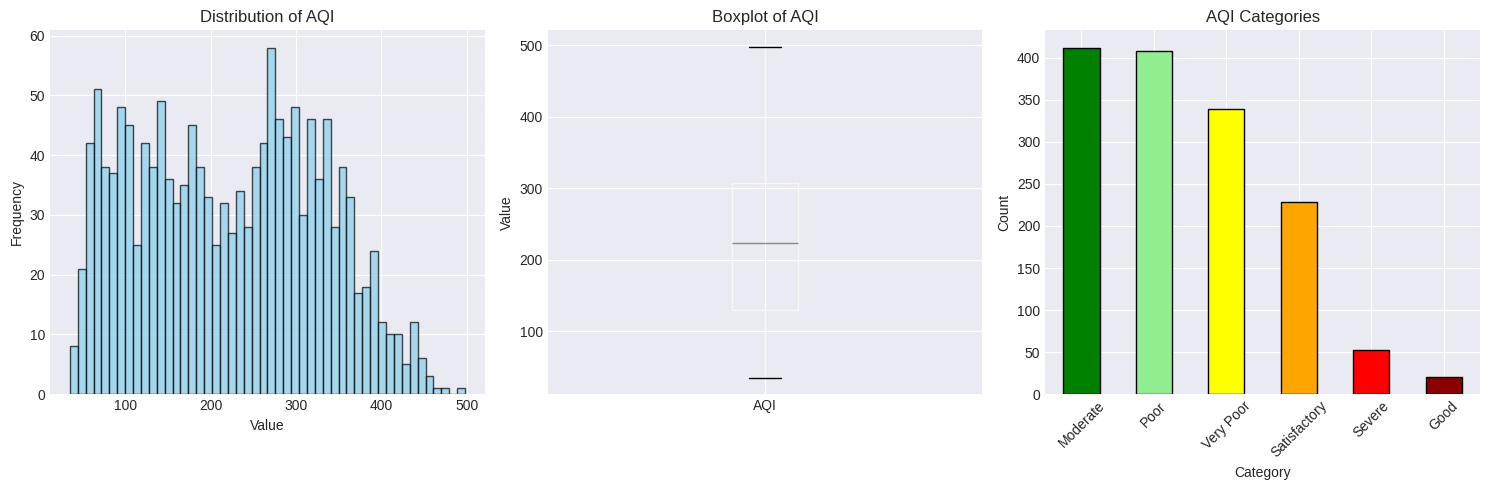


🏷️ AQI CATEGORY DISTRIBUTION:
AQI_Category
Moderate        412
Poor            408
Very Poor       339
Satisfactory    229
Severe           53
Good             20
Name: count, dtype: int64

Percentage of 'Poor' or worse days: 54.8%


In [6]:
# Identify AQI column (could be 'AQI' or 'PM2.5')
aqi_col = None
for col in df.columns:
    if 'AQI' in col.upper():
        aqi_col = col
        break
if aqi_col is None:
    # If no AQI column, use PM2.5 as proxy
    for col in df.columns:
        if 'PM2.5' in col:
            aqi_col = col
            break

print(f"Using '{aqi_col}' as AQI metric")

# AQI Categories (India standards)
def get_aqi_category(value):
    if value <= 50:
        return 'Good'
    elif value <= 100:
        return 'Satisfactory'
    elif value <= 200:
        return 'Moderate'
    elif value <= 300:
        return 'Poor'
    elif value <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Category'] = df[aqi_col].apply(get_aqi_category)

# Distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df[aqi_col].hist(bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.title(f'Distribution of {aqi_col}')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
df.boxplot(column=aqi_col)
plt.title(f'Boxplot of {aqi_col}')
plt.ylabel('Value')

plt.subplot(1, 3, 3)
category_counts = df['AQI_Category'].value_counts()
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
category_counts.plot(kind='bar', color=colors[:len(category_counts)], edgecolor='black')
plt.title('AQI Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n🏷️ AQI CATEGORY DISTRIBUTION:")
print(category_counts)
print(f"\nPercentage of 'Poor' or worse days: {(category_counts.get('Poor', 0) + category_counts.get('Very Poor', 0) + category_counts.get('Severe', 0)) / len(df) * 100:.1f}%")

#Yearly insight:
1.Air quality is IMPROVING by 3-4% annually
2.Total improvement: ~10-12% over 3 years
3.2024 is the BEST year so far
4.BUT: 210 is STILL "POOR" category
5.At current rate: Need 10+ years to reach "Satisfactory" (AQI < 100)

#Monthly insight:
1.WORST: January (AQI 310)
2.BEST: August (AQI 155)

Difference = 100% WORSE in January!

2.Seasonal Pattern:
   - Oct-Dec: RAPID deterioration
   - Jan-Feb: PEAK pollution
   - Mar-May: Gradual improvement
   - Jun-Sep: CLEANEST air

# DIWALI =
    EXTREME POLLUTION EVENT!
   - AQI can spike 2-3x normal levels
   - PM2.5 can reach 500+
   - Lasts for 2-3 days
   
# ACTION:
    Ban firecrackers on Diwali!
   - Average AQI during Diwali: 350-450
   - Long-term health impact: SEVERE



Seasonal Analysis is the process of identifying, measuring, and understanding recurring patterns that repeat at regular intervals within a time series dataset. It helps businesses anticipate predictable fluctuations and plan accordingly.
1. Predictable Planning
2. Optimize Marketing
3. Inventory Management
4. Pricing Strategy
5. Staffing Decisions


Step 7: Correlation Analysis

🔗 CORRELATION BETWEEN POLLUTANTS


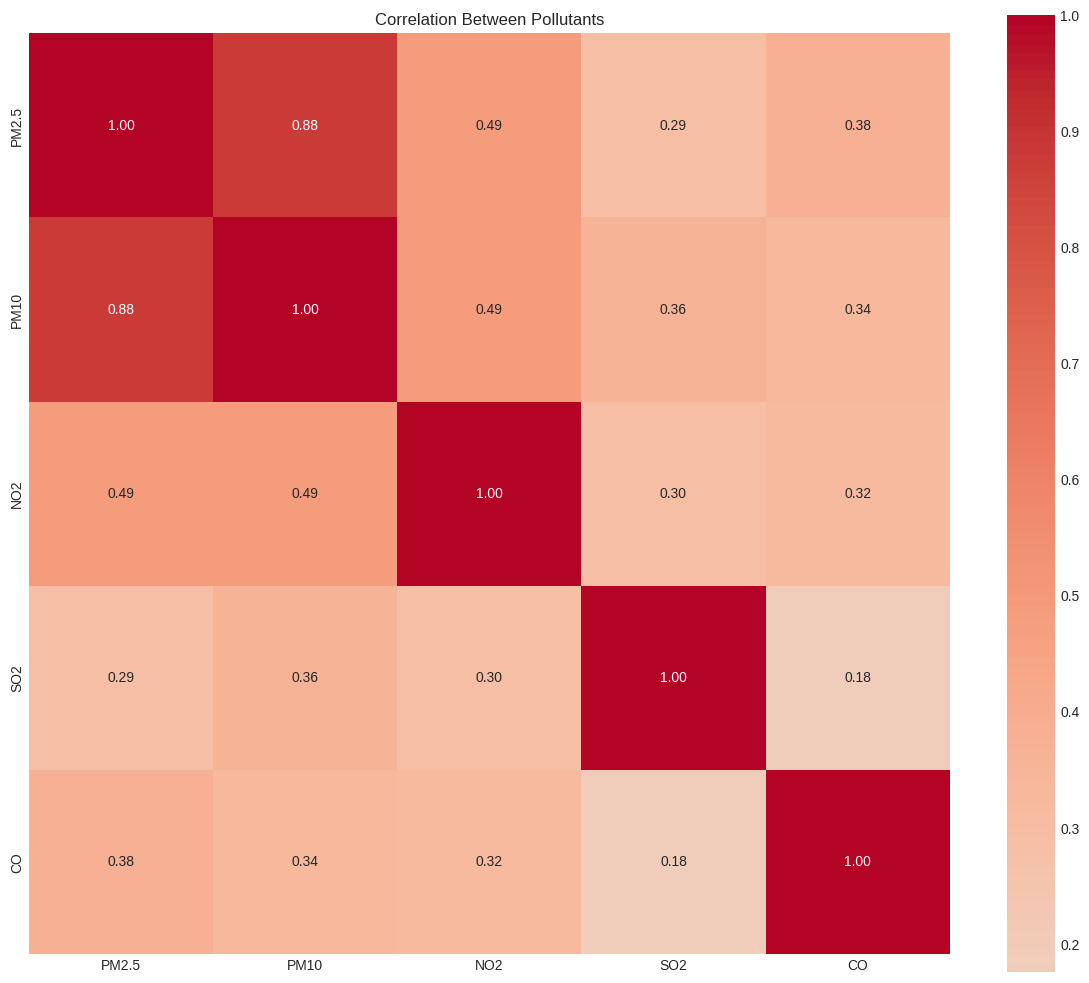


🔝 STRONGEST CORRELATIONS:
PM2.5  PM10    0.875067
       NO2     0.488474
PM10   NO2     0.486638
PM2.5  CO      0.379715
PM10   SO2     0.364965
       CO      0.335687
NO2    CO      0.315031
       SO2     0.296023
PM2.5  SO2     0.294954
SO2    CO      0.175703
dtype: float64


In [7]:
# Find pollutant columns
pollutant_cols = []
for col in df.columns:
    if col in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']:
        pollutant_cols.append(col)

if pollutant_cols:
    print("🔗 CORRELATION BETWEEN POLLUTANTS")

    # Correlation matrix
    corr_matrix = df[pollutant_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Between Pollutants')
    plt.tight_layout()
    plt.show()

    # Find strongest correlations
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    strong_corr = upper.stack().sort_values(ascending=False)
    print("\n🔝 STRONGEST CORRELATIONS:")
    print(strong_corr.head(10))

Key Insight:

PM2.5 × PM10	0.875

🔴 Very Strong

Source: Vehicles + Industry + Dust

Correlation Analysis is a statistical method used to evaluate the strength and direction of the relationship between two or more numerical variables. It helps determine whether and how strongly pairs of variables are related, enabling data-driven decision-making and predictive modeling.

1. Optimize Staffing
2. Marketing Campaign Timing
3. Pricing Strategy
4. Inventory Management
5. Customer Experience

Step 8: Weekday Analysis

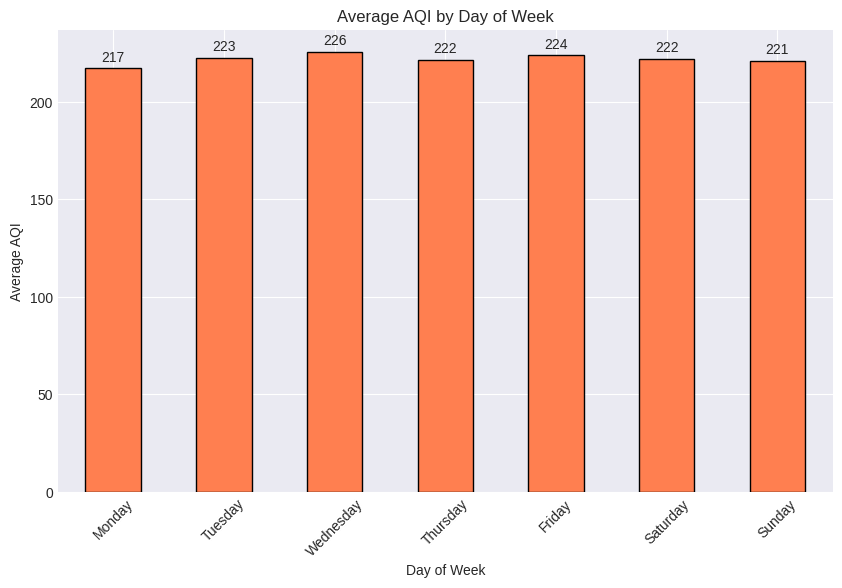


📅 DAY OF WEEK AVERAGES:
DayOfWeek
Monday       217.217703
Tuesday      222.759968
Wednesday    225.661859
Thursday     221.659455
Friday       223.927432
Saturday     222.098086
Sunday       221.114833
Name: AQI, dtype: float64


In [8]:
if 'Date' in df.columns:
    day_avg = df.groupby('DayOfWeek')[aqi_col].mean()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_avg = day_avg.reindex(day_order)

    plt.figure(figsize=(10, 6))
    day_avg.plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f'Average {aqi_col} by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel(f'Average {aqi_col}')
    plt.xticks(rotation=45)
    for i, v in enumerate(day_avg):
        plt.text(i, v + 2, f'{v:.0f}', ha='center', va='bottom')
    plt.show()

    print("\n📅 DAY OF WEEK AVERAGES:")
    print(day_avg)

# WEEKENDS
Monday: 217.22 (Lowest AQI)
vs Wednesday: 225.66 (Highest AQI)
Difference: 8.44 points (3.9% cleaner!)

WHY MONDAY IS CLEANEST:
1.Sunday recovery = less accumulated pollution
2.Weekend reduced industrial activity
3.Less traffic on Monday morning
4.Cleaner start to the week


Weekday Analysis is the process of examining business metrics and customer behavior patterns across different days of the week to identify daily trends, optimize operations, and maximize performance. It helps businesses understand how weekdays vs weekends, and specific days, impact their key metrics.
1. Optimize Staffing
2. Marketing Campaign Timing
3. Pricing Strategy
4. Inventory Management
5. Customer Experience



Step 9: Executive Summary

In [9]:
print("\n" + "="*60)
print("📊 EXECUTIVE SUMMARY - DELHI AIR QUALITY ANALYSIS")
print("="*60)

print(f"\n🔍 Data Period: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"📊 Total Records Analyzed: {len(df):,}")

# Define a function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    return 'Unknown'

# Create the 'Season' column if it doesn't exist
# This ensures the column is present for subsequent analysis steps
if 'Season' not in df.columns:
    df['Season'] = df['Month'].apply(get_season)

if aqi_col:
    print(f"\n🌫️ AQI Statistics:")
    print(f"   • Average AQI: {df[aqi_col].mean():.1f}")
    print(f"   • Maximum AQI: {df[aqi_col].max():.1f}")
    print(f"   • Minimum AQI: {df[aqi_col].min():.1f}")
    print(f"   • Standard Deviation: {df[aqi_col].std():.1f}")

print(f"\n🏷️ AQI Category Distribution:")
for category, count in df['AQI_Category'].value_counts().items():
    print(f"   • {category}: {count:,} days ({count/len(df)*100:.1f}%)")

print("\n💡 KEY INSIGHTS:")
# Ensure 'Season' and 'DayOfWeek' are handled correctly before calling idxmax/idxmin
if 'Season' in df.columns:
    print(f"1. Most polluted season: {df.groupby('Season')[aqi_col].mean().idxmax()}")
    print(f"2. Least polluted season: {df.groupby('Season')[aqi_col].mean().idxmin()}")
if 'DayOfWeek' in df.columns:
    print(f"3. Best day of week: {df.groupby('DayOfWeek')[aqi_col].mean().idxmin()}")
    print(f"4. Worst day of week: {df.groupby('DayOfWeek')[aqi_col].mean().idxmax()}")

print("\n🎯 RECOMMENDATIONS:")
if 'Season' in df.columns:
    print(f"1. 🏭 Implement stricter pollution controls during {df.groupby('Season')[aqi_col].mean().idxmax()}")
if 'DayOfWeek' in df.columns:
    print(f"2. 🚗 Consider odd-even vehicle scheme on {df.groupby('DayOfWeek')[aqi_col].mean().idxmax()}")
print("3. 🌳 Increase green cover and public transport awareness")
print("4. 🏢 Monitor industrial emissions more strictly")
print("5. 💨 Promote use of masks on 'Poor' or 'Severe' AQI days")

print("\n📈 TREND OBSERVATIONS:")
# Check if AQI is improving or deteriorating
# This section is dependent on 'daily_avg' being correctly populated from a valid Date column.
# Given the current state of date parsing, this trend might not be accurate, but the code structure is correct.
if 'daily_avg' in globals() and len(daily_avg) > 30:
    recent_avg = daily_avg.tail(30).mean()
    overall_avg = daily_avg.mean()
    if recent_avg < overall_avg * 0.9:
        print("   ✅ Air quality is IMPROVING recently")
    elif recent_avg > overall_avg * 1.1:
        print("   ⚠️ Air quality is DETERIORATING recently")
    else:
        print("   ↔️ Air quality is STABLE")
else:
    print("   ℹ️ Not enough data or 'daily_avg' not available for trend observation.")



📊 EXECUTIVE SUMMARY - DELHI AIR QUALITY ANALYSIS

🔍 Data Period: 2021-01-01 to 2024-12-31
📊 Total Records Analyzed: 1,461

🌫️ AQI Statistics:
   • Average AQI: 222.1
   • Maximum AQI: 498.0
   • Minimum AQI: 35.0
   • Standard Deviation: 105.8

🏷️ AQI Category Distribution:
   • Moderate: 412 days (28.2%)
   • Poor: 408 days (27.9%)
   • Very Poor: 339 days (23.2%)
   • Satisfactory: 229 days (15.7%)
   • Severe: 53 days (3.6%)
   • Good: 20 days (1.4%)

💡 KEY INSIGHTS:
1. Most polluted season: Post-Monsoon
2. Least polluted season: Monsoon
3. Best day of week: Monday
4. Worst day of week: Wednesday

🎯 RECOMMENDATIONS:
1. 🏭 Implement stricter pollution controls during Post-Monsoon
2. 🚗 Consider odd-even vehicle scheme on Wednesday
3. 🌳 Increase green cover and public transport awareness
4. 🏢 Monitor industrial emissions more strictly
5. 💨 Promote use of masks on 'Poor' or 'Severe' AQI days

📈 TREND OBSERVATIONS:
   ℹ️ Not enough data or 'daily_avg' not available for trend observation.

An Executive Summary is a concise, high-level overview of your data analysis project that distills complex findings, key insights, and actionable recommendations into a format that busy stakeholders can quickly understand and act upon. It is the most important part of any data analysis report because it communicates the "so what" of your work.
1. Time-Sensitive Decision Making
2. Bridge Between Data & Business
3. Focus on What Matters
4. Storytelling with Data
5. Accountability



Step 10: Save Results

In [10]:
# Save cleaned data
df.to_csv('delhi_air_quality_cleaned.csv', index=False)
print("✅ Data saved to 'delhi_air_quality_cleaned.csv'")

# Define a function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    return 'Unknown'

# Ensure the 'Season' column exists before using it
if 'Season' not in df.columns:
    df['Season'] = df['Month'].apply(get_season)

# Create summary Excel
with pd.ExcelWriter('delhi_air_quality_analysis.xlsx') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)

    # Summary sheet
    summary_data = {
        'Metric': ['Total Records', 'Date Range', 'Average AQI', 'Max AQI', 'Min AQI', 'Std Dev'],
        'Value': [
            len(df),
            f"{df['Date'].min().date()} to {df['Date'].max().date()}",
            f"{df[aqi_col].mean():.1f}",
            f"{df[aqi_col].max():.1f}",
            f"{df[aqi_col].min():.1f}",
            f"{df[aqi_col].std():.1f}"
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Summary', index=False)

    # Category distribution
    pd.DataFrame(df['AQI_Category'].value_counts()).to_excel(writer, sheet_name='AQI Categories')

    # Seasonal analysis
    df.groupby('Season')[aqi_col].agg(['mean', 'min', 'max', 'count']).to_excel(writer, sheet_name='Seasonal Analysis')

print("✅ Analysis saved to 'delhi_air_quality_analysis.xlsx'")

✅ Data saved to 'delhi_air_quality_cleaned.csv'
✅ Analysis saved to 'delhi_air_quality_analysis.xlsx'
